# Cross-Section Interpolation Surface

This notebook demonstrates `RasTerrain.compute_xs_interpolation_surface()` — the ras-commander
API equivalent of the RASMapper workflow: **Cross Sections → Interpolation Surface → Compute**.

The method reads cross-section cut lines, station/elevation data, bank stations, and river
geometry from either a geometry HDF (`.g##.hdf`) or plain-text geometry file (`.g##`),
then builds a Delaunay TIN interpolation surface clipped to the channel footprint.

**What you'll learn:**
- Build a channel-only TIN surface from a geometry HDF
- Write review layers to GeoPackage and a rasterized GeoTIFF
- Build a full-extent TIN surface from a plain-text geometry file
- Visualize interpolation points, triangles, and channel polygons
- Inspect surface metadata and compare channel vs full-extent results

**Prerequisites:**
- Python packages: `geopandas`, `shapely`, `scipy`, `matplotlib`
- Optional: `rasterio` (for GeoTIFF raster output)

## Setup and Imports

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
# Set USE_LOCAL_SOURCE based on your setup:
#   True  = Use local source code (for developers editing ras-commander)
#   False = Use pip-installed package (for users)
# =============================================================================

USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

# -----------------------------------------------------------------------------
if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)  # Parent of examples/ = repo root
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

from ras_commander import RasExamples, init_ras_project
from ras_commander.terrain import RasTerrain

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

LOCAL SOURCE MODE: Loading from G:\GH\ras-commander-wt-274/ras_commander


Loaded: G:\GH\ras-commander-wt-274\ras_commander\__init__.py


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
EXAMPLE_PROJECTS_ROOT = REPO_ROOT / "example_projects"

try:
    import rasterio
    RASTERIO_AVAILABLE = True
    print("rasterio available (GeoTIFF output enabled)")
except ImportError:
    RASTERIO_AVAILABLE = False
    print("rasterio not available - GeoTIFF output disabled")

rasterio available (GeoTIFF output enabled)


## Extract Example Project

We use the Muncie example project — a 1D HEC-RAS model with 61 cross sections,
bank stations, and GIS cut lines. This provides both geometry HDF and plain-text
geometry files for the two examples.

In [3]:
RasExamples.get_example_projects()

project_folder = RasExamples.extract_project(
    "Muncie",
    output_path=EXAMPLE_PROJECTS_ROOT,
    suffix="925",
)
ras = init_ras_project(project_folder, "6.5")

print(f"Project: {ras.project_name}")
print(f"Geometry files: {len(ras.geom_df)}")
print()
print(ras.geom_df[["geom_number", "geom_title", "full_path"]].to_string(index=False))

2026-05-29 11:03:17 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to G:\GH\ras-commander-wt-274\example_projects\Muncie_925


2026-05-29 11:03:17 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-29 11:03:17 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-29 11:03:17 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-05-29 11:03:17 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


...

2026-05-29 11:03:17 - ras_commander.RasPrj - INFO - ras-commander v0.96.2 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-29 11:03:17 - ras_commander.RasPrj - INFO - Project initialized: Muncie | Folder: G:\GH\ras-commander-wt-274\example_projects\Muncie_925


2026-05-29 11:03:17 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe


2026-05-29 11:03:17 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_

Project: Muncie
Geometry files: 3

geom_number                               geom_title                                                         full_path
         01             Muncie Base Geometry - 9 SAs G:\GH\ras-commander-wt-274\example_projects\Muncie_925\Muncie.g01
         02           Muncie Geometry - 2D 50ft Grid G:\GH\ras-commander-wt-274\example_projects\Muncie_925\Muncie.g02
         04 Muncie Geometry - 50ft User n Value Regi G:\GH\ras-commander-wt-274\example_projects\Muncie_925\Muncie.g04


In [4]:
# Locate the geometry HDF and plain-text geometry files
geom_plain = Path(ras.geom_df.iloc[0]["full_path"])
geom_hdf = Path(f"{geom_plain}.hdf")

print(f"Plain-text geometry: {geom_plain.name}  (exists: {geom_plain.exists()})")
print(f"Geometry HDF:        {geom_hdf.name}  (exists: {geom_hdf.exists()})")

Plain-text geometry: Muncie.g01  (exists: True)
Geometry HDF:        Muncie.g01.hdf  (exists: True)


## Example 1: Channel-Only Surface from Geometry HDF

The geometry HDF contains preprocessed cross-section data including
station/elevation arrays, GIS cut lines, bank stations, river centerlines,
and (if present) bank lines. This is the most common input path.

With `channel_only=True`, the surface is clipped between left and right
bank stations, producing a channel bathymetry interpolation.

In [5]:
# Output paths for review layers and raster
output_dir = project_folder / "XS_Surface"
output_dir.mkdir(exist_ok=True)

gpkg_path = output_dir / "xs_surface_channel.gpkg"
raster_path = output_dir / "xs_surface_channel.tif" if RASTERIO_AVAILABLE else None

channel_result = RasTerrain.compute_xs_interpolation_surface(
    geom_hdf,
    output_gpkg=gpkg_path,
    output_raster=raster_path,
    raster_cell_size=10.0,
    channel_only=True,
)

meta = channel_result["metadata"]
print(f"Source type:        {meta['source_type']}")
print(f"Cross sections:     {meta['cross_section_count']}")
print(f"Interpolation pts:  {meta['interpolation_point_count']}")
print(f"TIN triangles:      {meta['triangle_count']}")
print(f"Bank line source:   {meta['bank_line_source']}")
print(f"Footprint source:   {meta['footprint_source']}")
print(f"CRS:                {meta['crs']}")

if raster_path and raster_path.exists():
    print(f"\nRaster shape:       {meta['raster_shape']}")
    print(f"Valid cells:        {meta['raster_valid_cell_count']}")

print(f"\nGeoPackage written:  {gpkg_path.exists()}")
if raster_path:
    print(f"GeoTIFF written:     {raster_path.exists()}")

2026-05-29 11:03:17 - ras_commander.hdf.HdfXsec - WARNING - No river bank lines found in geometry file


2026-05-29 11:03:18 - pyogrio._io - INFO - Created 3,290 records


2026-05-29 11:03:18 - pyogrio._io - INFO - Created 1,739 records


2026-05-29 11:03:18 - pyogrio._io - INFO - Created 1 records


2026-05-29 11:03:18 - pyogrio._io - INFO - Created 61 records


2026-05-29 11:03:18 - pyogrio._io - INFO - Created 2 records


2026-05-29 11:03:18 - pyogrio._io - INFO - Created 1 records


2026-05-29 11:03:18 - ras_commander.terrain.RasTerrain - INFO - Computed XS interpolation surface from Muncie.g01.hdf: 61 cross sections, 1739 points, 3290 triangles


Source type:        geometry_hdf
Cross sections:     61
Interpolation pts:  1739
TIN triangles:      3290
Bank line source:   xs_bank_stations
Footprint source:   channel_banks
CRS:                PROJCS["NAD_1983_StatePlane_Indiana_East_FIPS_1301_Feet",GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",328083.3333333333],PARAMETER["False_Northing",820208.3333333333],PARAMETER["Central_Meridian",-85.66666666666667],PARAMETER["Scale_Factor",0.9999666666666667],PARAMETER["Latitude_Of_Origin",37.5],UNIT["Foot_US",0.3048006096012192]]

Raster shape:       (511, 898)
Valid cells:        32526

GeoPackage written:  True
GeoTIFF written:     True


### Visualize Channel Surface

Plot the TIN triangles colored by mean elevation, overlaid with
interpolation points and the channel footprint polygon.

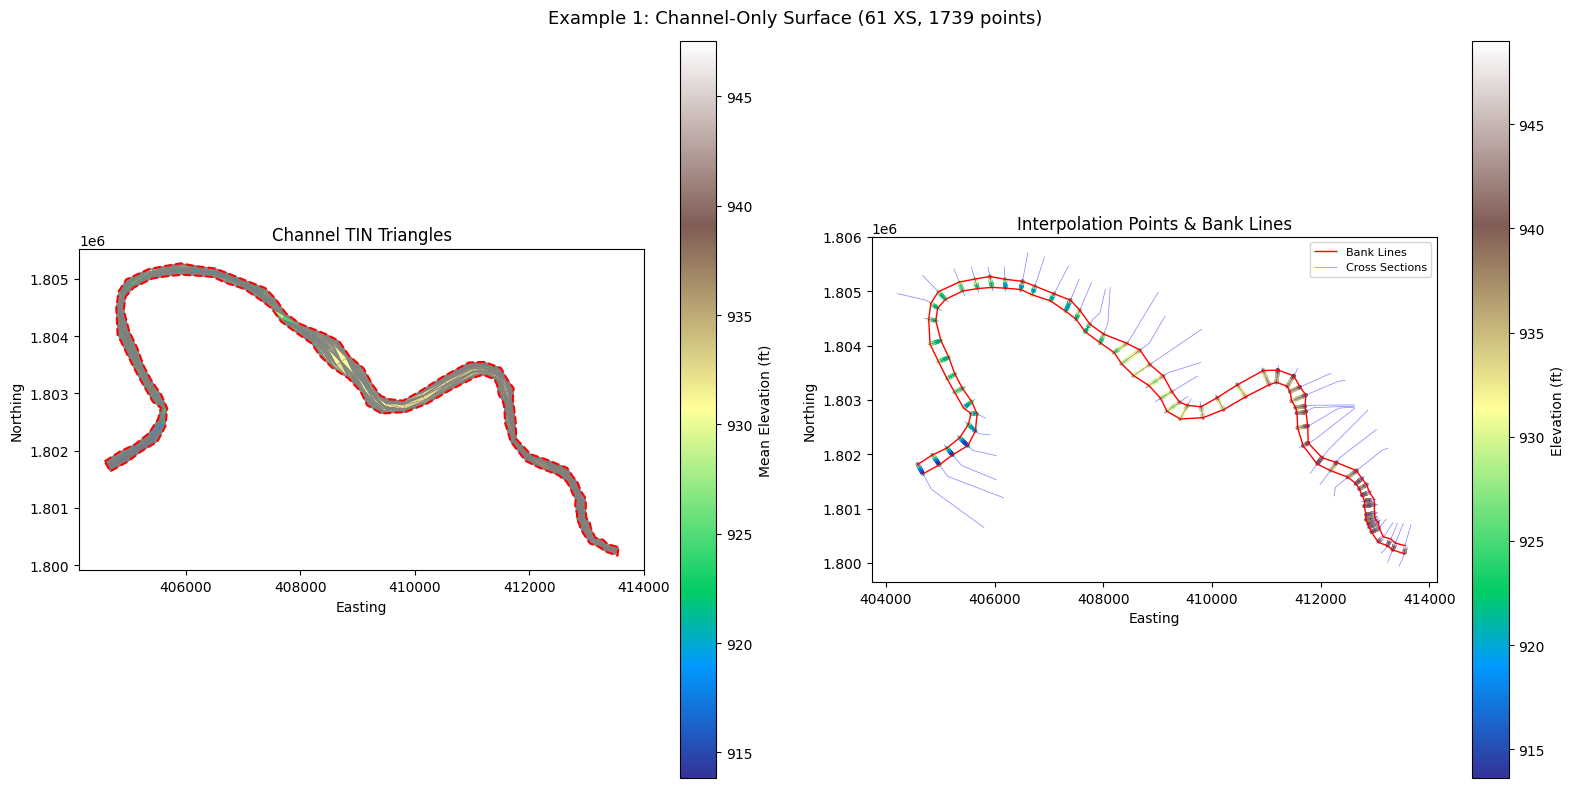

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: TIN triangles colored by mean elevation
ax = axes[0]
channel_result["triangles"].plot(
    ax=ax, column="z_mean", cmap="terrain", edgecolor="gray",
    linewidth=0.3, legend=True, legend_kwds={"label": "Mean Elevation (ft)"},
)
channel_result["channel_polygon"].boundary.plot(
    ax=ax, color="red", linewidth=1.5, linestyle="--",
)
ax.set_title("Channel TIN Triangles")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

# Right: Interpolation points colored by elevation
ax = axes[1]
channel_result["points"].plot(
    ax=ax, column="elevation", cmap="terrain", markersize=4,
    legend=True, legend_kwds={"label": "Elevation (ft)"},
)
if not channel_result["bank_lines"].empty:
    channel_result["bank_lines"].plot(
        ax=ax, color="red", linewidth=1.0, label="Bank Lines",
    )
if not channel_result["cross_sections"].empty:
    channel_result["cross_sections"].plot(
        ax=ax, color="blue", linewidth=0.5, alpha=0.5, label="Cross Sections",
    )
ax.set_title("Interpolation Points & Bank Lines")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.legend(loc="upper right", fontsize=8)

plt.suptitle(f"Example 1: Channel-Only Surface ({meta['cross_section_count']} XS, {meta['interpolation_point_count']} points)", fontsize=13)
plt.tight_layout()
plt.show()

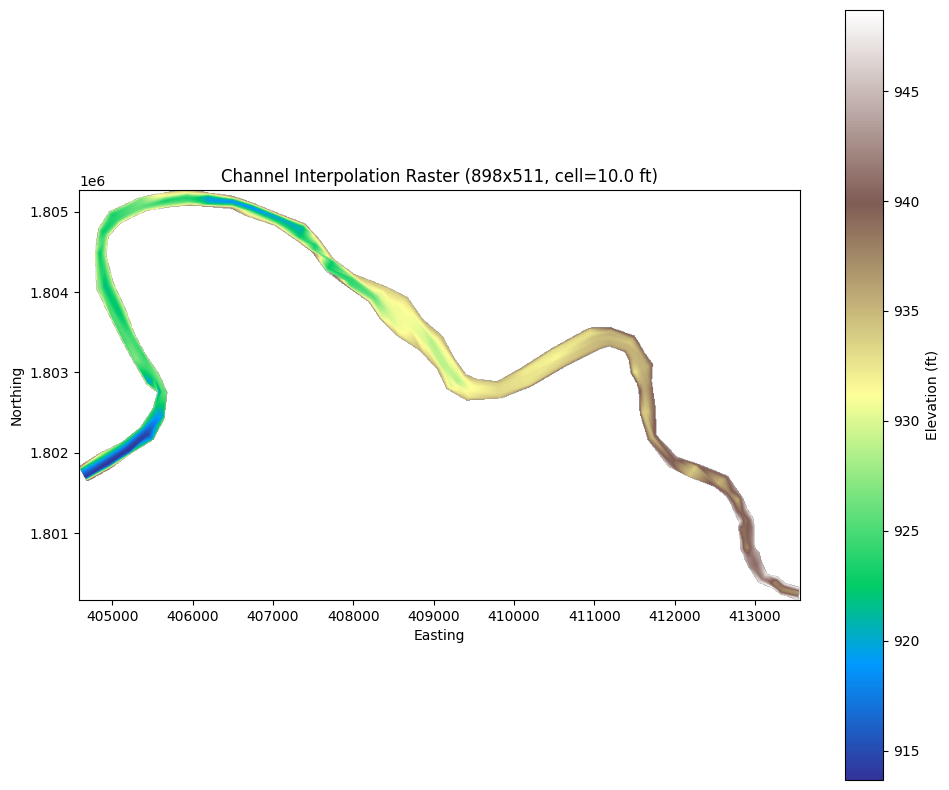

Elevation range: 913.66 to 948.69 ft
Valid cells: 32526 / 458878 (7.1%)


In [7]:
# Raster visualization (if rasterio available)
if channel_result["raster"] is not None:
    array = channel_result["raster"]["array"]
    nodata = channel_result["raster"]["nodata"]
    bounds = channel_result["raster"]["bounds"]

    display_array = np.where(array == nodata, np.nan, array)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(
        display_array, cmap="terrain",
        extent=[bounds[0], bounds[2], bounds[1], bounds[3]],
        origin="upper",
    )
    plt.colorbar(im, ax=ax, label="Elevation (ft)")
    ax.set_title(f"Channel Interpolation Raster ({meta['raster_shape'][1]}x{meta['raster_shape'][0]}, cell={meta['raster_cell_size']} ft)")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")
    plt.tight_layout()
    plt.show()

    valid = array[array != nodata]
    print(f"Elevation range: {valid.min():.2f} to {valid.max():.2f} ft")
    print(f"Valid cells: {valid.size} / {array.size} ({100 * valid.size / array.size:.1f}%)")
else:
    print("Raster output skipped (rasterio not available)")

## Example 2: Full-Extent Surface from Plain-Text Geometry

The plain-text geometry file (`.g##`) contains cross-section station/elevation
data and embedded GIS cut lines. With `channel_only=False`, the surface extends
to the full cross-section extents (left overbank to right overbank).

Plain-text input requires a CRS override since the `.g##` file doesn't embed
projection information. Muncie uses NAD83 / UTM Zone 16N (EPSG:26916).

In [8]:
full_result = RasTerrain.compute_xs_interpolation_surface(
    geom_plain,
    channel_only=False,
    crs="EPSG:26916",
)

meta_full = full_result["metadata"]
print(f"Source type:        {meta_full['source_type']}")
print(f"Cross sections:     {meta_full['cross_section_count']}")
print(f"Interpolation pts:  {meta_full['interpolation_point_count']}")
print(f"TIN triangles:      {meta_full['triangle_count']}")
print(f"Footprint source:   {meta_full['footprint_source']}")

2026-05-29 11:03:20 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: G:\GH\ras-commander-wt-274\example_projects\Muncie_925\Muncie.g01


2026-05-29 11:03:20 - ras_commander.geom.GeomParser - INFO - Found 61 XS cut lines


2026-05-29 11:03:20 - ras_commander.geom.GeomParser - INFO - Extracting river centerlines from: G:\GH\ras-commander-wt-274\example_projects\Muncie_925\Muncie.g01


2026-05-29 11:03:20 - ras_commander.geom.GeomParser - INFO - Found 1 river centerlines


2026-05-29 11:03:21 - ras_commander.terrain.RasTerrain - INFO - Computed XS interpolation surface from Muncie.g01: 61 cross sections, 5158 points, 10019 triangles


Source type:        plain_geometry
Cross sections:     61
Interpolation pts:  5158
TIN triangles:      10019
Footprint source:   xs_extents


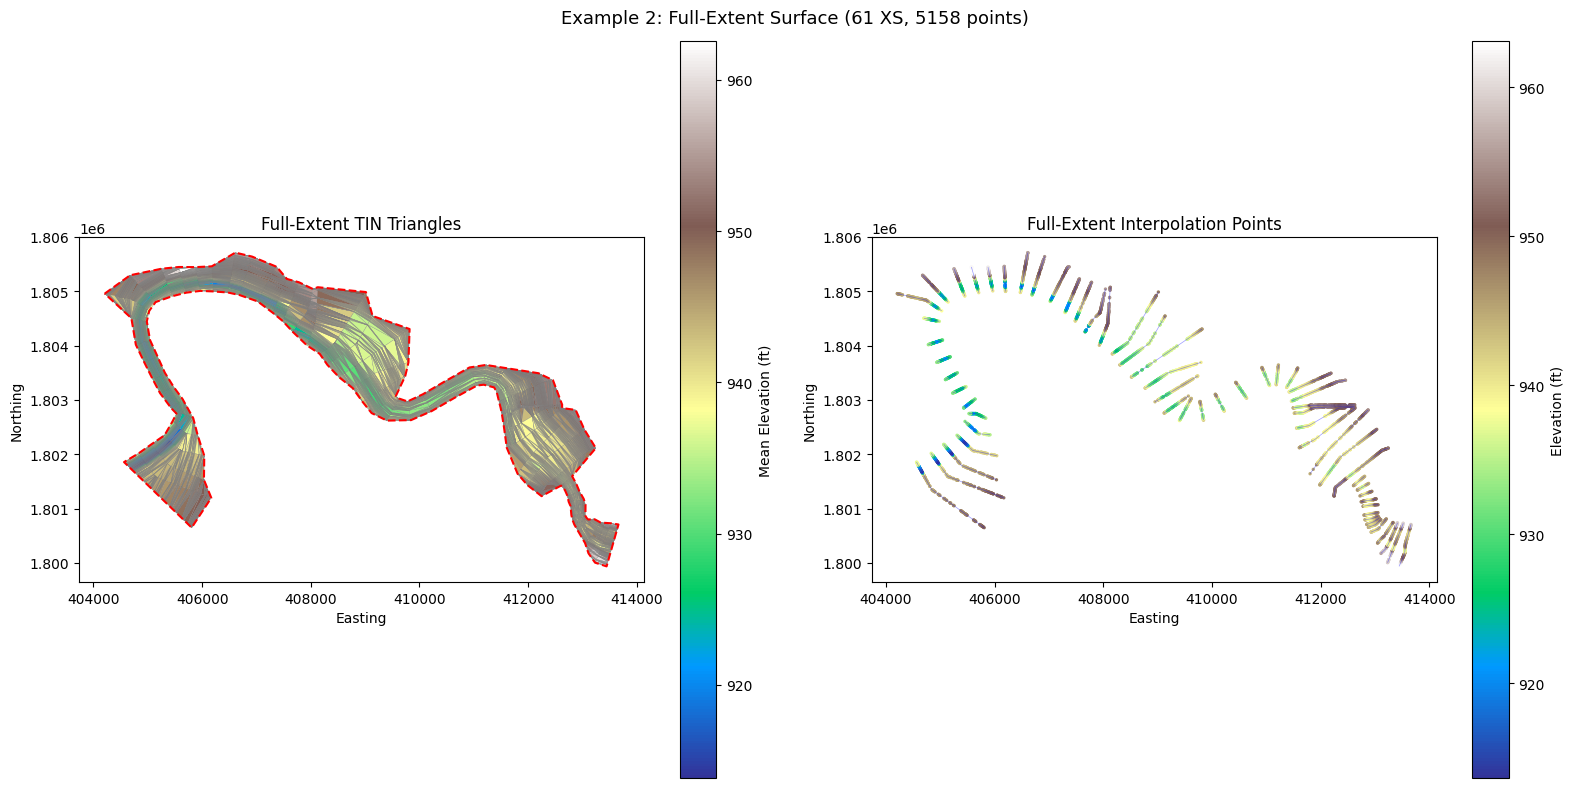

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Full-extent TIN triangles
ax = axes[0]
full_result["triangles"].plot(
    ax=ax, column="z_mean", cmap="terrain", edgecolor="gray",
    linewidth=0.2, legend=True, legend_kwds={"label": "Mean Elevation (ft)"},
)
full_result["channel_polygon"].boundary.plot(
    ax=ax, color="red", linewidth=1.5, linestyle="--",
)
ax.set_title("Full-Extent TIN Triangles")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

# Right: All interpolation points
ax = axes[1]
full_result["points"].plot(
    ax=ax, column="elevation", cmap="terrain", markersize=2,
    legend=True, legend_kwds={"label": "Elevation (ft)"},
)
if not full_result["cross_sections"].empty:
    full_result["cross_sections"].plot(
        ax=ax, color="blue", linewidth=0.5, alpha=0.4,
    )
ax.set_title("Full-Extent Interpolation Points")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

plt.suptitle(f"Example 2: Full-Extent Surface ({meta_full['cross_section_count']} XS, {meta_full['interpolation_point_count']} points)", fontsize=13)
plt.tight_layout()
plt.show()

## Comparison: Channel-Only vs Full-Extent

Compare the two modes side by side to understand how `channel_only` affects
the interpolation footprint and point count.

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Source type",
        "Cross sections",
        "Interpolation points",
        "TIN triangles",
        "Bank line source",
        "Footprint source",
    ],
    "Channel-Only (HDF)": [
        meta["source_type"],
        meta["cross_section_count"],
        meta["interpolation_point_count"],
        meta["triangle_count"],
        meta["bank_line_source"],
        meta["footprint_source"],
    ],
    "Full-Extent (Plain Text)": [
        meta_full["source_type"],
        meta_full["cross_section_count"],
        meta_full["interpolation_point_count"],
        meta_full["triangle_count"],
        meta_full["bank_line_source"],
        meta_full["footprint_source"],
    ],
})

print(comparison.to_string(index=False))
print(f"\nFull-extent has {meta_full['interpolation_point_count'] - meta['interpolation_point_count']} more points than channel-only")

              Metric Channel-Only (HDF) Full-Extent (Plain Text)
         Source type       geometry_hdf           plain_geometry
      Cross sections                 61                       61
Interpolation points               1739                     5158
       TIN triangles               3290                    10019
    Bank line source   xs_bank_stations         xs_bank_stations
    Footprint source      channel_banks               xs_extents

Full-extent has 3419 more points than channel-only


## Key Takeaways

1. **Two input paths**: Geometry HDF (`*.g##.hdf`) auto-resolves CRS from the file;
   plain-text geometry (`*.g##`) requires an explicit `crs=` parameter.

2. **Channel-only vs full-extent**: `channel_only=True` clips to bank stations,
   producing a focused channel bathymetry surface. `channel_only=False` uses
   full cross-section extents for overbank interpolation.

3. **Review layers**: The GeoPackage contains triangles, points, channel polygon,
   cross sections, bank lines, and river centerlines — open in QGIS or ArcGIS
   to visually QC the interpolation before using it in a terrain.

4. **Raster output**: The GeoTIFF can be used as a channel bathymetry raster
   input to `RasTerrain.create_terrain_hdf()` for multi-source terrain creation
   (channel raster over overbank DEM).

### Adapting for Your Project

```python
from ras_commander.terrain import RasTerrain

result = RasTerrain.compute_xs_interpolation_surface(
    geom_path="MyProject.g01.hdf",     # or "MyProject.g01" for plain text
    output_gpkg="review_layers.gpkg",   # QC in QGIS/ArcGIS
    output_raster="channel.tif",        # for terrain creation
    raster_cell_size=5.0,               # in project units
    channel_only=True,                  # True for bathymetry, False for full XS
)
```